In [1]:
!pip install sentence-transformers seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\Kahani Tharayil\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sentences = [
    "The batsman scored a century in the final match",
    "The bowler delivered a fast yorker to take the wicket",
    "Fielders saved crucial runs near the boundary line",
    "The team celebrated their victory after a thrilling chase",
    "The chef prepared a spicy curry with fresh ingredients",
    "Baking requires precise measurements and timing",
    "She garnished the dish with herbs and spices",
    "Strong passwords help protect against cyber attacks",
    "Encryption ensures that sensitive data remains secure",
    "Firewalls prevent unauthorized access to networks"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11454.68it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
similarity_matrix = cosine_similarity(embeddings, embeddings)
similarity_matrix

array([[ 1.0000001 ,  0.43000692,  0.3053018 ,  0.3038435 ,  0.14594467,
         0.14740169, -0.01174258,  0.03512906,  0.04647063, -0.01452629],
       [ 0.43000692,  1.0000001 ,  0.35675344,  0.19129664,  0.2521136 ,
         0.13842192,  0.12675771,  0.07311887,  0.00382756, -0.01902137],
       [ 0.3053018 ,  0.35675344,  1.        ,  0.26588562, -0.00938496,
         0.0953472 ,  0.05190689,  0.08560839,  0.10164206,  0.03103939],
       [ 0.3038435 ,  0.19129664,  0.26588562,  1.        ,  0.02644369,
        -0.04756944,  0.03457316,  0.01150944, -0.01981704,  0.04794136],
       [ 0.14594467,  0.2521136 , -0.00938496,  0.02644369,  1.        ,
         0.14002585,  0.437639  ,  0.02834851,  0.0182547 ,  0.01132358],
       [ 0.14740169,  0.13842192,  0.0953472 , -0.04756944,  0.14002585,
         1.0000002 ,  0.11076878, -0.03016847,  0.07886538, -0.00834477],
       [-0.01174258,  0.12675771,  0.05190689,  0.03457316,  0.437639  ,
         0.11076878,  1.0000002 , -0.02651531

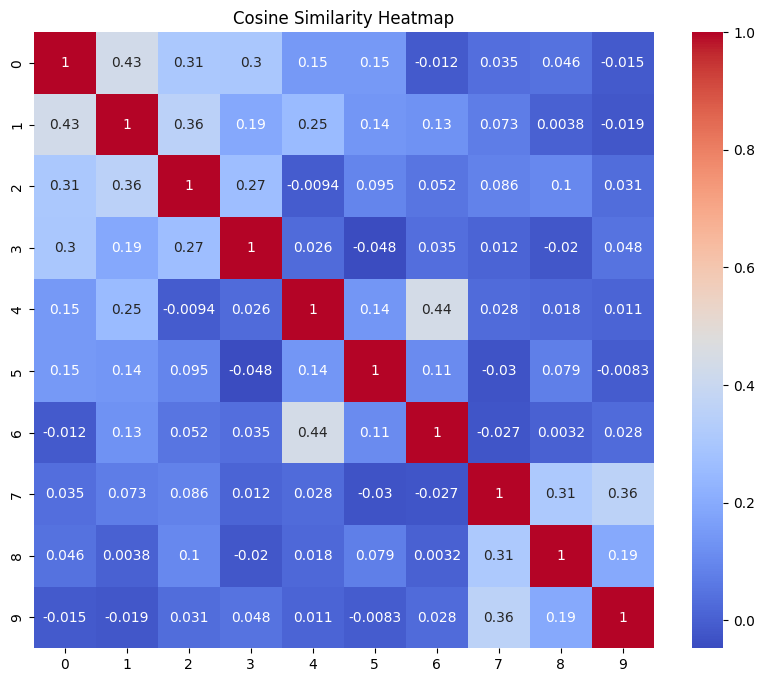

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Heatmap")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", round(similarities[idx], 4))
    print()

Sentence: The bowler delivered a fast yorker to take the wicket
Similarity Score: 0.6663

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

